In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [42]:
df= pd.read_csv("C:\\Users\\sampada\\machine-learning-journey\\handling missing values\\imputation technique\\titanic_toy.csv",usecols =['Age','Fare','Survived'])

In [44]:
df.head()

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [46]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Survived     0.000000
dtype: float64

In [48]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [50]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [54]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [56]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]=X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()]=X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\sampada\AppData\Local\Temp\ipykernel_7456\1306450744.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()]=X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
C:

In [62]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


array([21.  , 36.  , 17.  ,  9.  , 28.  , 24.  , 21.  , 17.  , 30.  ,
       24.  ,  9.  ,  4.  , 24.  , 36.  , 17.  , 27.  , 70.  , 54.  ,
       35.  , 19.  , 29.  , 37.  , 43.  , 25.  , 45.  , 42.  ,  6.  ,
       18.  , 25.  , 50.  ,  0.42, 27.  , 18.  , 27.  , 40.  , 21.  ,
       30.  , 40.  ,  2.  , 29.  , 30.  , 20.  , 34.  , 24.  , 36.  ,
       25.  , 26.  , 30.  ,  4.  , 30.  , 16.  , 25.  , 24.  , 58.  ,
       36.  , 18.  ,  4.  , 29.  , 26.  ,  5.  , 23.  , 24.  , 30.  ,
       41.  , 43.  , 25.  , 28.  , 14.5 , 28.  , 32.5 , 71.  , 46.  ,
       48.  , 28.  , 18.  , 31.  , 50.  , 22.  , 20.  , 23.  ,  1.  ,
       38.  , 51.  , 30.  , 30.  , 51.  , 42.  , 34.  , 21.  ,  3.  ,
       28.  , 35.  , 27.  , 58.  , 59.  , 35.  , 24.  , 39.  , 31.  ,
       47.  , 16.  , 29.  , 40.  , 23.  , 31.  , 29.  , 52.  , 34.  ,
        5.  , 24.  , 42.  , 35.  , 39.  ,  8.  , 33.  , 45.  ,  4.  ,
       33.  , 29.  , 36.  , 59.  , 23.  , 17.  ,  8.  , 20.  , 30.  ,
        2.  , 19.  ,

In [64]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,9.0
493,71.0,49.5042,71.0
527,NaN,221.7792,14.0


C:\Users\sampada\AppData\Local\Temp\ipykernel_7456\2922253437.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='original',hist=False)
C:\Users\sampada\AppData\Local\Temp\ipykernel_7456\2922253437.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_trai

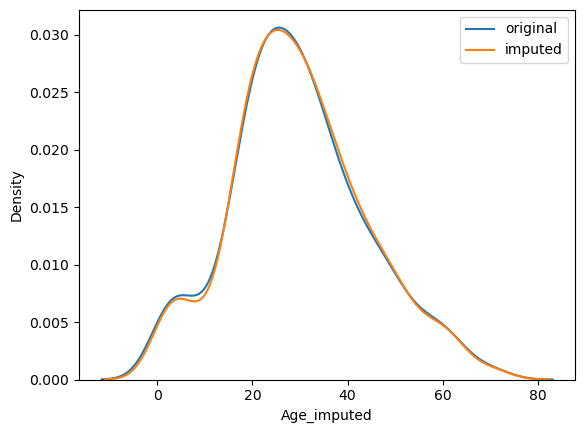

In [68]:
sns.distplot(X_train['Age'],label='original',hist=False)
sns.distplot(X_train['Age_imputed'],label='imputed',hist=False)
plt.legend()
plt.show()

In [72]:
print('Original:',X_train['Age'].var())
print('Imputed:',X_train['Age_imputed'].var())

Original: 204.3495133904614
Imputed: 200.1450395168619


In [76]:
X_train[['Fare','Age','Age_imputed']].cov() #covariance changes

,Fare,Age,Age_imputed
Fare,2448.197914,70.719262,45.295160
Age,70.719262,204.349513,204.349513
Age_imputed,45.295160,204.349513,200.145040


In [ ]:
sampled_value = X_train['Age'].dropna().sample(1,random_state=int(observation['Fare']))
# produced same sample for given random state

## Categorical data

In [127]:
data = pd.read_csv("C:\\Users\\sampada\\machine-learning-journey\\handling missing values\\imputation technique\\train.csv",usecols=['SalePrice', 'GarageQual', 'FireplaceQu'])

In [129]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [131]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [133]:
X = data
y = data['SalePrice' ]

In [136]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [138]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']


In [ ]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()]=X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()]=X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()]=X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()]=X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [142]:
temp = pd.concat(
    [ X_train['GarageQual'].value_counts()/len(X_train['GarageQual'].dropna()),
     X_train['GarageQual_imputed'].value_counts()/len(X_train)],axis=1,keys=['Original','Imputed'])


In [144]:
temp

,Original,Imputed
TA,0.951043,0.898116
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [146]:
temp = pd.concat(
    [ X_train['FireplaceQu'].value_counts()/len(X_train['FireplaceQu'].dropna()),
     X_train['FireplaceQu_imputed'].value_counts()/len(X_train)],axis=1,keys=['Original','Imputed'])

In [148]:
temp

,Original,Imputed
Gd,0.494272,0.258562
TA,0.412439,0.215753
Fa,0.040917,0.021404
Po,0.027823,0.014555
Ex,0.024550,0.012842
